This code recovers the original functions and generates new points, usually out of the rank used initially

In [32]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import pickle
import random
random.seed(a=1111)

In [33]:
# Network Architecture
ILS = 1 #Input layer size
NL, LS = 5, 10 # Number of hidden layers and their size

# Import weights from original file
def import_w(file):
    with open(file, 'rb') as f:
        w = pickle.load(f)
    return w
    
# Compute output
def compute_output(invals, w, activation_fun):
    # Input layer
    cl = np.array(invals)
    # Hidden layers
    for l in range(len(w)-1):
        #print(len(w[l][0]))
        cl = np.array([np.sum([w[l][i][j]*cl[i] for i in range(len(cl))]) for j in range(len(w[l][0]))])
        if activation_fun=='tanh':
            cl = np.tanh(cl)
        elif activation_fun=='ReLU':
            cl=[cl_i if cl_i>0 else 0 for cl_i in cl]
        elif activation_fun=='leaky_ReLU':
            cl=[cl_i if cl_i>0 else 0.01*cl_i for cl_i in cl]
            
        
    return(np.sum([w[-1][i][0] * cl[i] for i in range(len(w[-1]))]))

In [34]:
NREP = 10 #Number of functions you want to generate
xmin=-2;xmax=14 #limits of x 

resolution='1x'
resolutions={'0.5x':0.1, '1x':0.05, '2x': 0.025, '4e-3x':0.004 }

step=resolutions[resolution]



d_all = pd.DataFrame({'x1' : [], 'y': [], 'rep': []}) #initialize dataframe to for normalized functions
d_all_raw = pd.DataFrame({'x1' : [], 'y_raw': [], 'rep': []}) #initialize dataframe for non-normalized functions

activation_function='leaky_ReLU' #tanh, ReLU, leaky_ReLU . Activation functions for neural network

filename = 'NN_weights_' + activation_function + '_NREP_10_.pickle'
weights = import_w('../../data/backup_data/' + filename)

    
for rep in range(NREP):

    w=weights[rep]
                
    #initialize x and generate y values
    x1 = np.arange(xmin, xmax, step)
    x1s, ys = [], []
    y = [compute_output([1, thisx1], w, activation_function) for thisx1 in x1]
    x1s=x1
    ys=y
    
    # Normalize functions
    ys = np.array(ys)
    ys_norm = (ys - min(ys)) / (max(ys) - min(ys) + 1e-15)

    #Save normalized functions to dataframes
    d = pd.DataFrame({'x1' : x1s, 'y' : ys_norm, 'rep': rep})
    d_all=pd.concat([d_all,d])
    
    #Save non-normalized version
    d_raw = pd.DataFrame({'x1' : x1s, 'y_raw' : ys, 'rep': rep})
    d_all_raw=pd.concat([d_all_raw,d_raw])

    display(d_raw)
    display(d)

#Save weights to pickle and dataframes to csvs
save=True
if save==True:
    with open('../../data/generative_data/' + 'NN_weights_' + str(activation_function) + '_NREP_' + str(NREP) + '_ILS%d_NL%d_LS%d'  %(ILS, NL,  LS) +'.pickle', 'wb') as f:
        pickle.dump(weights, f, protocol=None)

    d_all.to_csv('../../data/out_of_rank/' + 'NN_out_rank_function_' + str(activation_function) + '_NREP_' + str(NREP) + '_res_' + str(step) + '_data.csv')
    d_all_raw.to_csv('../../data/out_of_rank/' + 'non_normalized_out_of_rank_function_' + str(activation_function) + '_NREP_' + str(NREP) + '_ILS%d_NL%d_LS%d'  %(ILS, NL,  LS) + '_data.csv')

,x1,y_raw,rep
0,-2.00,0.000508,0
1,-1.95,0.000508,0
2,-1.90,0.000508,0
3,-1.85,0.000508,0
4,-1.80,0.000508,0
...,...,...,...
315,13.75,0.080072,0
316,13.80,0.080362,0
317,13.85,0.080652,0
318,13.90,0.080942,0


,x1,y,rep
0,-2.00,0.001005,0
1,-1.95,0.001006,0
2,-1.90,0.001007,0
3,-1.85,0.001008,0
4,-1.80,0.001008,0
...,...,...,...
315,13.75,0.985643,0
316,13.80,0.989232,0
317,13.85,0.992822,0
318,13.90,0.996411,0


,x1,y_raw,rep
0,-2.00,-0.018892,1
1,-1.95,-0.021625,1
2,-1.90,-0.024359,1
3,-1.85,-0.027093,1
4,-1.80,-0.029827,1
...,...,...,...
315,13.75,-2.716520,1
316,13.80,-2.726482,1
317,13.85,-2.736443,1
318,13.90,-2.746405,1


,x1,y,rep
0,-2.00,0.993055,1
1,-1.95,0.992063,1
2,-1.90,0.991072,1
3,-1.85,0.990080,1
4,-1.80,0.989088,1
...,...,...,...
315,13.75,0.014455,1
316,13.80,0.010841,1
317,13.85,0.007227,1
318,13.90,0.003614,1


,x1,y_raw,rep
0,-2.00,-1.717958,2
1,-1.95,-1.694998,2
2,-1.90,-1.672038,2
3,-1.85,-1.649078,2
4,-1.80,-1.626118,2
...,...,...,...
315,13.75,-8.762309,2
316,13.80,-8.789906,2
317,13.85,-8.817504,2
318,13.90,-8.845101,2


...

,x1,y,rep
0,-2.00,0.171002,7
1,-1.95,0.166291,7
2,-1.90,0.161580,7
3,-1.85,0.156868,7
4,-1.80,0.152157,7
...,...,...,...
315,13.75,0.987091,7
316,13.80,0.990311,7
317,13.85,0.993531,7
318,13.90,0.996764,7


,x1,y_raw,rep
0,-2.00,0.009035,8
1,-1.95,0.008879,8
2,-1.90,0.008774,8
3,-1.85,0.008669,8
4,-1.80,0.008564,8
...,...,...,...
315,13.75,0.060059,8
316,13.80,0.060265,8
317,13.85,0.060472,8
318,13.90,0.060678,8


,x1,y,rep
0,-2.00,0.113652,8
1,-1.95,0.110983,8
2,-1.90,0.109185,8
3,-1.85,0.107387,8
4,-1.80,0.105590,8
...,...,...,...
315,13.75,0.985877,8
316,13.80,0.989408,8
317,13.85,0.992938,8
318,13.90,0.996469,8


,x1,y_raw,rep
0,-2.00,-0.616319,9
1,-1.95,-0.595893,9
2,-1.90,-0.575467,9
3,-1.85,-0.555041,9
4,-1.80,-0.534616,9
...,...,...,...
315,13.75,-14.985246,9
316,13.80,-15.037816,9
317,13.85,-15.090387,9
318,13.90,-15.142957,9


,x1,y,rep
0,-2.00,0.972074,9
1,-1.95,0.973436,9
2,-1.90,0.974798,9
3,-1.85,0.976160,9
4,-1.80,0.977522,9
...,...,...,...
315,13.75,0.014021,9
316,13.80,0.010515,9
317,13.85,0.007010,9
318,13.90,0.003505,9


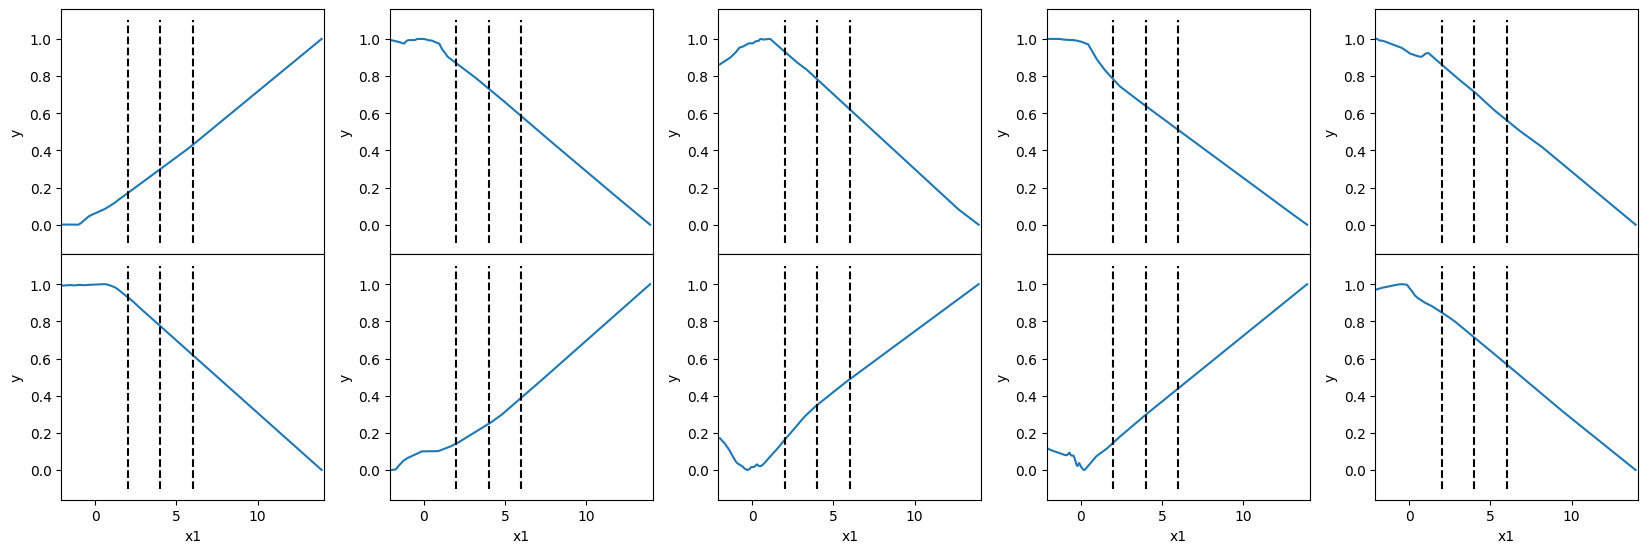

In [35]:
#PLOT FIGURES

#Figure Size                                                                                                                                                                                                
cm = 1/2.54  # centimeters in inches                                                                                                                                                                        
width=45*cm;height=14*cm #Width and height of plots 
matplotlib.rcParams['figure.figsize'] = [width, height]

rows=2;cols=5
gs=gridspec.GridSpec(rows,cols)
gs.update(left=0.1,right=0.99,bottom=0.08,top=0.97,wspace=0.25,hspace=0.0)

#Plot train rank (xmin,xmax)
h=0
for r in range(rows):
    for c in range(cols):
        ax_rc=plt.subplot(gs[r,c])
        d=d_all[d_all['rep']==h]
        ax_rc=sns.lineplot(data=d, x='x1', y='y')
        ax_rc.vlines(x=[2, 4, 6], ymin=-0.1, ymax=1.1, color='k',linestyle='--')
        ax_rc.set_xlim(xmin-0.1,xmax+0.1)
        h+=1
plt.savefig('../../results/seminal_data/' + 'out_of_rank_function_' + activation_function + '_' + 'ILS%d_NL%d_LS%d'  %(ILS, NL,  LS) + '.png', dpi=300)